# (23) Retina: white noise analysis

host: ```mach```, device: ```cuda:0```

**motivation:** <br>

Kyoto16-bw

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Load

In [3]:
# a = 'gaussian+gompertz_Kyoto16-bw_t-8_b-16_k-[128]_u-(7,2),du-(7,3)'
# b = 'debug-fisher-xi_b200-ep800-lr(0.005)_gr(300)_(2025_04_22,23:42)'

# a = 'gaussian+logistic_Kyoto16-bw_t-8_b-16_k-[256]_u-(7,2),du-(7,3)'
# b = 'debug-fisher-xi_b200-ep800-lr(0.005)_gr(300)_(2025_04_22,22:59)'

# a = 'gaussian+logistic_Kyoto16-bw_t-8_b-16_k-[128]_u-(7,2),du-(7,3)'
# b = 'debug-fisher-xi_b200-ep800-lr(0.005)_gr(300)_(2025_04_22,23:43)'

### TODO: test this after convergence

a = 'gaussian+logistic_Kyoto16-bw_t-8_b-8_k-[128]_u-(7,2),du-(7,3)'
b = 'b200-ep800-lr(0.005)_gr(300)_(2025_04_23,19:37)'

### TODO: test this after testing the above

# a = 'gaussian+logistic_Kyoto16-bw_t-8_b-8_k-[256]_u-(7,2),du-(7,3)'
# b = 'b200-ep800-lr(0.005)_gr(300)_(2025_04_23,19:36)'

tr, meta = load_model(pjoin(a, b), device=device)
meta['checkpoint']

800

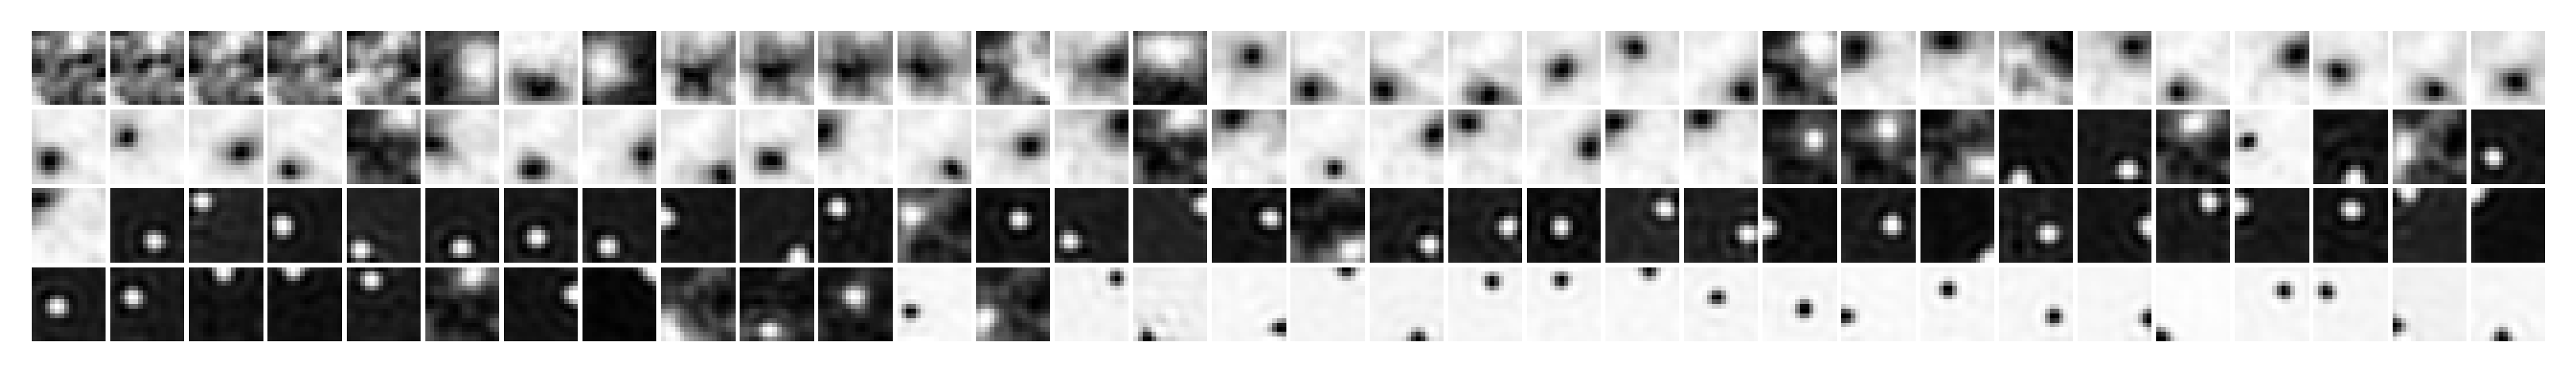

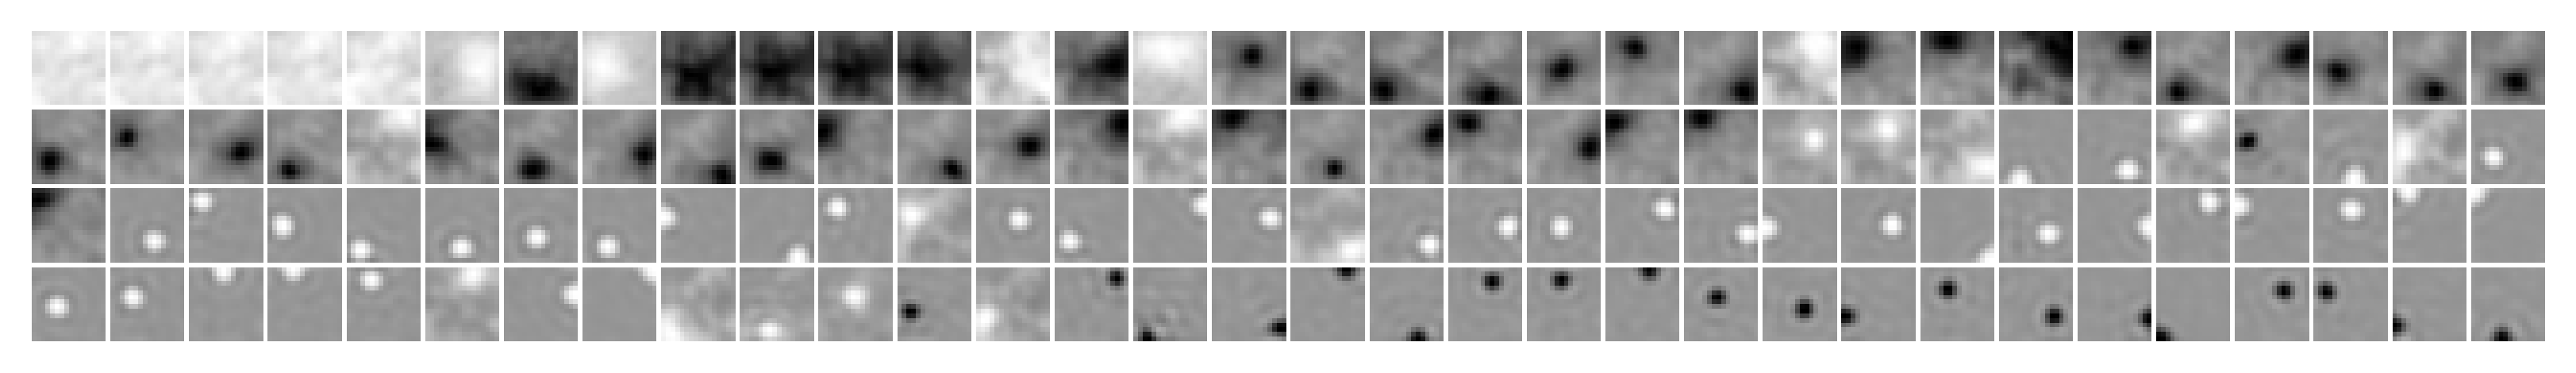

In [4]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), dpi=400)
tr.model.show(order=np.argsort(u0), dpi=400, method='abs-max');

In [5]:
print([llr.exp() for llr in tr.model.layer.log_lr])

[
    tensor([0.0930], device='cuda:0', grad_fn=<ExpBackward0>),
    tensor([0.0219], device='cuda:0', grad_fn=<ExpBackward0>)
]

## White noise

In [6]:
from analysis.sta import perform_sta_analysis
from utils.animation import show_movie

In [7]:
n_lags = 70
sta = perform_sta_analysis(tr, n_lags=n_lags, n_trials=200, batch_size=20_000)

sta.shape

100%|███████████████████████████████████████| 200/200 [2:00:12<00:00, 36.06s/it]


torch.Size([128, 71, 256])

In [8]:
order = np.argsort(u0)
sta = sta[order]

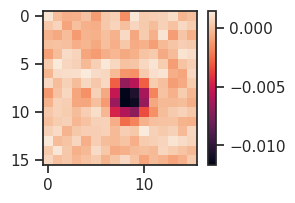

In [10]:
imshow(sta[-10, -1].reshape(16, 16))
plt.colorbar()

In [11]:
show_movie(sta[-10].reshape(-1, 16, 16), n_frames=-1)

In [12]:
s_kers = np_nans((len(sta), 16, 16))
t_kers = np_nans((len(sta), n_lags + 1))

for i in range(len(sta)):
    uu, ss, vvh = torch.linalg.svd(sta[i], full_matrices=False)
    s_kers[i] = tonp(vvh[0]).reshape(16, 16)
    t_kers[i] = tonp(uu[:, 0])

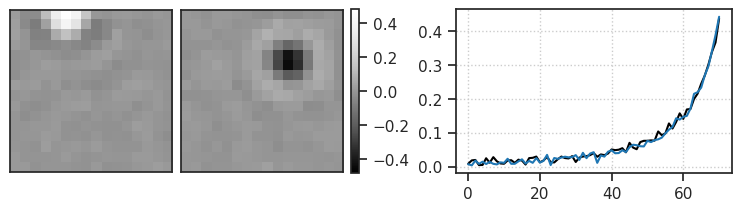

In [13]:
i, j = 99, 124
vminmax = np.abs(s_kers[[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[i], color='k')
axes[2].plot(t_kers[j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

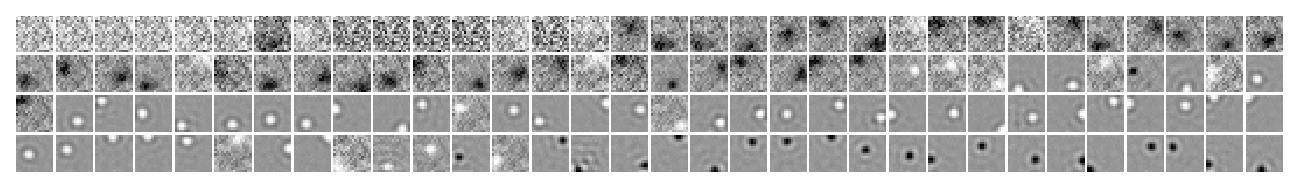

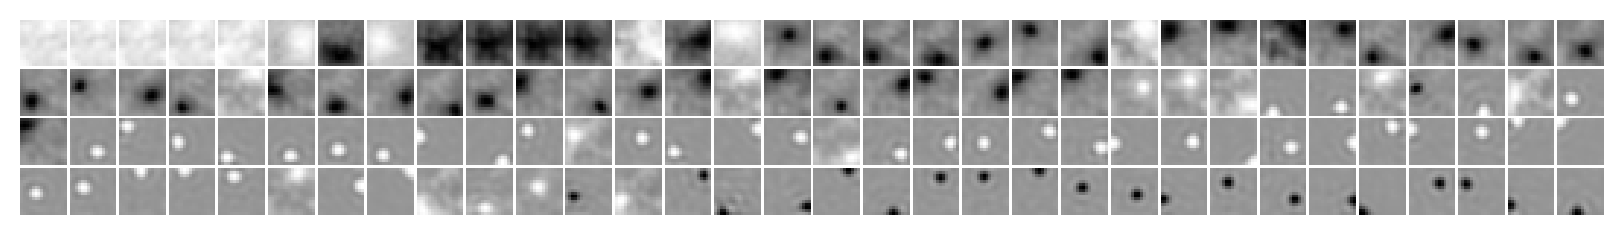

In [14]:
plot_weights(s_kers, method='abs-max');
tr.model.show(order=order, method='abs-max');

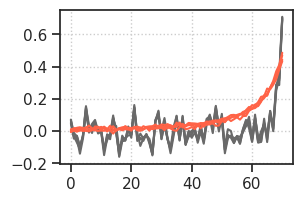

In [15]:
plot(t_kers[:4].T, color='dimgrey');
plot(t_kers[-8:-4].T, color='tomato');
plt.grid()
plt.show()

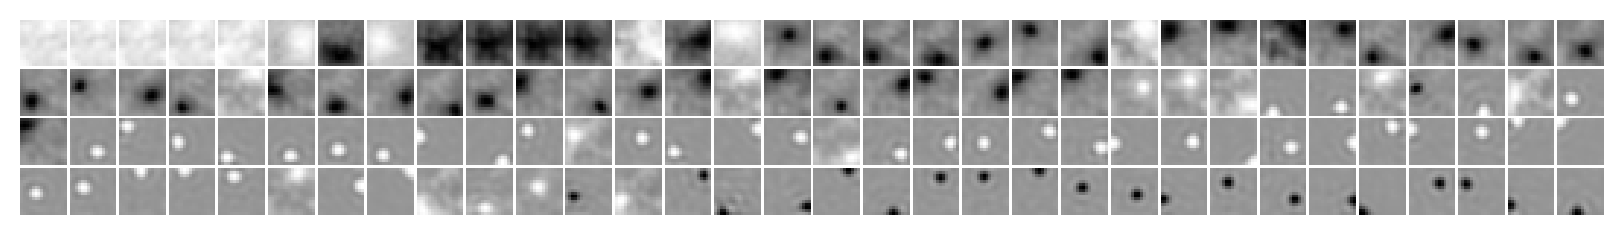

In [16]:
tr.model.show(order=order, method='abs-max');

In [17]:
w = tonp(tr.model.layer.get_weight().T)[order]
w.shape

(128, 256)

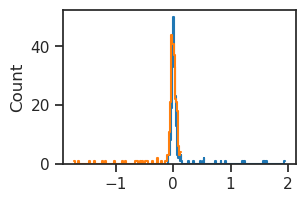

In [18]:
histplot(w[99])
histplot(w[124]);

<Axes: ylabel='Count'>

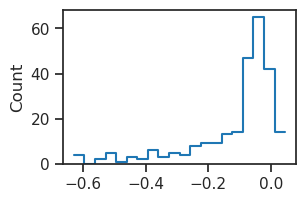

In [19]:
histplot(w[32])

In [91]:
rng = get_rng(0)

batch_size = 500

noise_mean = 0.0
noise_sigma = 1.0

noise_kws = dict(
    loc=noise_mean,
    scale=noise_sigma,
    size=(batch_size, 1, 16, 16),
)
nosie = rng.normal(**noise_kws)

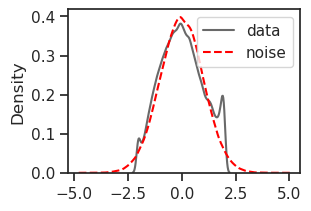

In [93]:
fig, ax = create_figure()

sns.kdeplot(tonp(tr.dl_vld.dataset.tensors[0][:1000]).ravel(), label='data', color='dimgrey', ax=ax)
sns.kdeplot(nosie.ravel(), label='noise', color='red', ls='--', ax=ax)

add_legend(ax)
plt.show()